In [1]:
!pip install segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 5.8 MB/s eta 0:00:00


In [2]:
import os
import torch
import wandb
import math
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import skimage as ski
import albumentations as A

from sklearn.model_selection import train_test_split

import torchvision.transforms as transforms
import torchvision.transforms.functional as TF
from torchvision.transforms import v2
from torch.utils.data import Dataset, DataLoader, SubsetRandomSampler
from sklearn.model_selection import train_test_split, KFold

import torch.nn as nn
import torch.nn.functional as F
import segmentation_models_pytorch as smp

In [3]:
# Get cpu, gpu or mps device for training.
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using cuda device


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
EXPERIMENT = "development" # "development" or "uba"

#Base Hyperparameters
learning_rate = 5e-4
epochs = 16
batch_size = 4

image_height, image_width = 240, 480

# Loss Hyperparameters
alpha = 0.5

# Learning Rate Scheduler Hyperparameters
warmup_epochs = np.ceil(epochs * 0.25)
warmup_factor = .1

# Fold Setup
k_folds = 5
fold = 4  # <-- choose which fold you want

N_landmarks = 17
HG_blocks = 4
pretrained_model_path = "/content/drive/MyDrive/PhD/ITHILDIN/landmark/segmentation_weights_fold-1.pth"
path = "/content/drive/MyDrive/PhD/ITHILDIN/landmark/"


In [6]:
file_list = np.load(os.path.join(path,"traindata", "forlandmark_{}_images.npy".format(EXPERIMENT)))
heatmap_list = np.load(os.path.join(path,"traindata", "forlandmark_{}_heatmap.npy".format(EXPERIMENT)))
path_list = np.load(os.path.join(path,"traindata", "forlandmark_{}_paths.npy".format(EXPERIMENT)))

In [7]:
# Create KFold splitter
kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)

# Generate all fold splits
splits = list(kf.split(np.arange(len(file_list))))

# Select the fold you want
train_idx, test_idx = splits[fold]

train_file_list = file_list[train_idx]
test_file_list = file_list[test_idx]

train_label_list = heatmap_list[train_idx]
test_label_list = heatmap_list[test_idx]

train_path_list = path_list[train_idx]
test_path_list = path_list[test_idx]

In [8]:
class CustomDataset(Dataset):
    """
    Expected inputs:
    - file_image: array-like of shape (N, H, W, C) with values in [0, 255] or similar
    - file_heatmap: array-like of shape (N, H, W, K) with values in [0, 255] or similar
    - file_path: list/array of strings or identifiers for each sample
    - augment_transforms: callable augment(image_tensor) -> image_tensor
                        (optional). This should accept and return a torch.Tensor
                        with shape (C, H, W). If None, no extra augment is applied.
    - augment_bool: bool controlling whether to apply geo_transform + augment_transforms
    """

    def __init__(self, file_image, file_heatmap, file_path, augment_transforms=None, augment_bool=False):
        self.images = file_image
        self.heatmap = file_heatmap
        self.paths = file_path
        self.augment = augment_transforms
        self.augment_bool = augment_bool

    def __len__(self):
        return len(self.images)

    def geo_transform(self, image: torch.Tensor, heatmap: torch.Tensor, mask: torch.Tensor = None):
        # Random rotation angle between -5 and 5 degrees
        angle = float(torch.empty(1).uniform_(-5, 5).item())

        # Rotate image and heatmap with bilinear interpolation
        image = TF.rotate(image, angle, interpolation=TF.InterpolationMode.BILINEAR, expand=False)
        heatmap = TF.rotate(heatmap, angle, interpolation=TF.InterpolationMode.BILINEAR, expand=False)

        if mask.dim() == 2:
            mask = mask.unsqueeze(0)
        mask = TF.rotate(mask, angle, interpolation=TF.InterpolationMode.NEAREST, expand=False)

        # Random horizontal flip with 50% prob for all tensors
        if torch.rand(1).item() > 0.5:
            image = TF.hflip(image)
            heatmap = TF.hflip(heatmap)
            mask = TF.hflip(mask)

        return image, heatmap, mask

    def minmax_scale_per_layer(self, tensor: torch.Tensor):
        """
        Min-max scale each channel independently to [0,1].
        tensor shape: (C, H, W)
        """
        if tensor.dim() != 3:
            raise ValueError("minmax_scale_per_layer expects a tensor with shape (C, H, W)")
        c, h, w = tensor.shape
        scaled = torch.empty_like(tensor)
        for i in range(c):
            layer = tensor[i]
            min_val = float(layer.min())
            max_val = float(layer.max())
            if max_val > min_val:
                scaled[i] = (layer - min_val) / (max_val - min_val)
            else:
                scaled[i] = torch.zeros_like(layer)
        return scaled

    def CLAHE_transform(self, image: torch.Tensor):
        # Convert to grayscale by averaging channels -> (H, W)
        # Work on CPU numpy for skimage functions
        grayscale = image.mean(dim=0).cpu().numpy()
        # CLAHE (adaptive histogram equalization)
        equalized = ski.exposure.equalize_adapthist(grayscale, clip_limit=0.1, nbins=128)
        # Median filter to reduce noise
        equalized = ski.filters.median(equalized, ski.morphology.disk(2))

        return torch.tensor(equalized, dtype=torch.float32)

    def __getitem__(self, idx):
        # Load Data from numpy-like arrays and convert immediately to torch tensors in C,H,W layout
        # Assumes stored arrays are (H, W, C)
        img_np = self.images[idx].astype(np.float32)
        heat_np = self.heatmap[idx].astype(np.float32)
        path = self.paths[idx]

        # Use floating point torch tensors, channel-first
        image = torch.from_numpy(img_np).permute(2, 0, 1).float().div(255.0)  # (C, H, W)
        heatmap = torch.from_numpy(heat_np).permute(2, 0, 1).float().div(255.0)  # (K, H, W)

        # Foreground mask determined from first image channel
        mask = (image[0] != 0)  # (H, W) boolean
        mask_tensor = mask.float().unsqueeze(0)  # (1, H, W)

        # Augment Data (geometric + optional extra augment)
        if self.augment_bool:
            # Apply the SAME geometric transform to image, heatmap, and mask
            image, heatmap, mask_tensor = self.geo_transform(image, heatmap, mask_tensor)
            image = self.augment(image)

        # mask_tensor is (1, H, W) float -> threshold/round to boolean
        mask = mask_tensor.squeeze(0).round().bool()  # (H, W)

        # Generate Loss weights: sum spatially across all heatmap channels, then repeat per-channel
        summed = heatmap.sum(dim=0, keepdim=False)  # (H, W)
        weight = summed.unsqueeze(0).repeat(heatmap.shape[0], 1, 1)  # (K, H, W)

        # Smooth Landmarks and weights with gaussian blur
        # gaussian_blur accepts (C,H,W) tensors
        heatmap = TF.gaussian_blur(heatmap, kernel_size=(5, 5), sigma=(13.0,))
        weight = TF.gaussian_blur(weight, kernel_size=(5, 5), sigma=(13.0,))

        # Grayscale + CLAHE transform (returns (H, W))
        image = torch.clamp(image, min=0.0, max=1.0)
        image_gray = self.CLAHE_transform(image)

        # set all values outside the mask to 0
        image_gray[~mask] = 0.0

        # add channel dimension back -> (1, H, W)
        image_out = image_gray.unsqueeze(0)

        # Normalize heatmap and weight per-channel
        heatmap = self.minmax_scale_per_layer(heatmap)
        weight = self.minmax_scale_per_layer(weight)

        # Final clamps
        heatmap = torch.clamp(heatmap, min=0.0, max=1.0)
        weight = torch.clamp(weight, min=0.0, max=1.0)

        return (image_out, heatmap, weight, path)

In [9]:
augment_transforms = transforms.Compose([v2.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.1),
                                  v2.GaussianBlur(kernel_size=3, sigma=(0.75, 1.25)),
                                  v2.RandomPosterize(bits=8, p=0.1),
                                  v2.RandomAutocontrast(p=0.2),
                                  v2.RandomAdjustSharpness(sharpness_factor=1.5, p=0.2),
                                  v2.RandomGrayscale(p=.2),])

segment_trans = A.Compose([A.PixelDropout(dropout_prob=0.1, p=.5),
                        A.CoarseDropout(p=1, num_holes_range=(3, 15), hole_height_range=(5, 25), hole_width_range=(5, 25),),
                        A.Morphological(scale=(1,3), operation="dilation", p=.5),
                        A.Morphological(scale=(1,3), operation="erosion", p=0.5),
                        A.MedianBlur((3,5), p=0.75),
                        ])

train_file_list = file_list[train_idx]
test_file_list = file_list[test_idx]

train_label_list = heatmap_list[train_idx]
test_label_list = heatmap_list[test_idx]

train_path_list = path_list[train_idx]
test_path_list = path_list[test_idx]

# Create an instance of the CustomDataset
train_dataset = CustomDataset(file_image = train_file_list,
                              file_heatmap = train_label_list,
                              file_path = train_path_list,
                              augment_transforms=augment_transforms,
                              augment_bool=True)


test_dataset = CustomDataset(file_image = test_file_list,
                              file_heatmap = test_label_list,
                              file_path = test_path_list,
                              augment_transforms=None,
                              augment_bool=False)

# Create dataloaders
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=12)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=12)

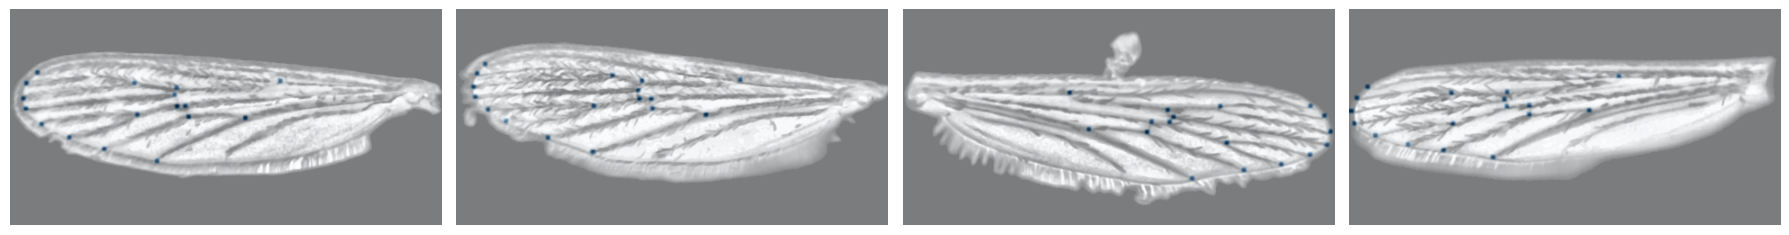

In [10]:
#Preview
fig, axes = plt.subplots(1,4, figsize=(18, 4))
ax = axes.ravel()

image_batch, heatmap_batch, weigth_batch, path_batch = next(iter(train_dataloader))

for i in range(4):
    image = image_batch.numpy()[i][0]
    image = ski.transform.resize(image, (240, 480), anti_aliasing=False, order=1)
    heatmap = np.sum(heatmap_batch.numpy()[i], axis=0)

    ax[i].imshow(image, cmap='gray')
    ax[i].imshow(heatmap, cmap='Blues', alpha=0.5)

for a in ax.ravel(): a.axis('off')
plt.tight_layout()

In [11]:
class CoordConv(nn.Module):
    """
    CoordConv layer that appends normalized x and y coordinate channels
    to the input tensor before applying a standard 2D convolution.
    """
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1):
        super(CoordConv, self).__init__()
        # Add 2 to in_channels to account for x and y coordinate channels
        self.conv = nn.Conv2d(in_channels + 2, out_channels, kernel_size, stride, padding)

    def forward(self, x):
        batch_size, _, height, width = x.size()
        device = x.device

        # Generate x and y coordinate grids normalized to [-1, 1]
        yy_channel, xx_channel = torch.meshgrid(
            torch.linspace(-1, 1, height, device=device),
            torch.linspace(-1, 1, width, device=device),
            indexing="ij"
        )

        # Expand to batch size
        xx_channel = xx_channel.unsqueeze(0).expand(batch_size, 1, height, width)
        yy_channel = yy_channel.unsqueeze(0).expand(batch_size, 1, height, width)

        # Concatenate coordinate channels to input
        coord_channels = torch.cat([xx_channel, yy_channel], dim=1)
        x = torch.cat([x, coord_channels], dim=1)

        return self.conv(x)


class ConvBlock(nn.Module):
    """
    A basic convolutional block: Conv2d -> GroupNorm -> LeakyReLU.
    """
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1):
        super(ConvBlock, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding)
        self.bn = nn.GroupNorm(num_groups=8, num_channels=out_channels)
        self.relu = nn.LeakyReLU(inplace=True)

    def forward(self, x):
        return self.relu(self.bn(self.conv(x)))


class Hourglass(nn.Module):
    """
    Hourglass network for landmark localization, enhanced with CoordConv and segmentation map conditioning.
    """
    def __init__(self, in_channels, num_blocks=4, intermediate_channels=64, output_channels=N_landmarks):
        """
        Args:
            in_channels (int): Number of input image channels (e.g., 1 for grayscale).
            num_blocks (int): Number of downsampling/upsampling blocks.
            intermediate_channels (int): Feature size in intermediate layers.
            output_channels (int): Number of output heatmap channels (landmarks).
        """
        super(Hourglass, self).__init__()
        self.num_blocks = num_blocks

        # Downsampling path
        self.coord_convs = nn.ModuleList()
        self.down_blocks = nn.ModuleList()

        for i in range(num_blocks):
            input_ch = in_channels if i == 0 else intermediate_channels
            # +1 to input for segmentation map
            self.coord_convs.append(CoordConv(input_ch + 1, intermediate_channels))
            self.down_blocks.append(ConvBlock(intermediate_channels, intermediate_channels))

        # Bottleneck block (lowest resolution)
        self.bottleneck = ConvBlock(intermediate_channels, intermediate_channels)

        # Upsampling path
        self.up_blocks = nn.ModuleList()
        for _ in range(num_blocks):
            self.up_blocks.append(ConvBlock(intermediate_channels, intermediate_channels))

        # Final output block to produce landmark heatmaps
        self.output_block = nn.Sequential(
            ConvBlock(intermediate_channels, intermediate_channels),
            nn.Conv2d(intermediate_channels, output_channels, kernel_size=1, stride=1, padding=0)
        )

    def forward(self, image, segmentation):
        """
        Forward pass for the hourglass model.

        Args:
            image (Tensor): Input image tensor of shape (B, C, H, W).
            segmentation (Tensor): Segmentation map of shape (B, 1, H, W).

        Returns:
            Tensor: Output heatmaps for landmarks of shape (B, output_channels, H, W).
        """
        x = torch.cat([image, segmentation], dim=1)  # Combine inputs

        skip_connections = []

        # Downsampling with CoordConv + ConvBlock + MaxPool
        for i in range(self.num_blocks):
            x = self.coord_convs[i](x)
            x = self.down_blocks[i](x)
            skip_connections.append(x)
            x = F.max_pool2d(x, kernel_size=2, stride=2, ceil_mode=True)

            # Resize segmentation to match new spatial size and concatenate again
            if i < self.num_blocks - 1:
                segmentation = F.interpolate(segmentation, size=x.shape[2:], mode='nearest')
                x = torch.cat([x, segmentation], dim=1)

        # Bottleneck processing
        x = self.bottleneck(x)

        # Upsampling with skip connections
        for i, up in enumerate(self.up_blocks):
            # Upsample and add skip connection
            x = F.interpolate(x, size=skip_connections[-(i + 1)].shape[2:], mode='nearest')
            x = x + skip_connections[-(i + 1)]
            x = up(x)

        return self.output_block(x)


def get_model():
    """
    Instantiates the Hourglass model, loads pretrained weights, and returns it.

    Returns:
        Hourglass: The landmark detection model with loaded weights.
    """
    HG_blocks = 4  # Number of hourglass levels

    # Initialize model
    landmark_model = Hourglass(
        in_channels=1,
        num_blocks=HG_blocks,
        intermediate_channels=64,
        output_channels=N_landmarks
    )

    return landmark_model

class AddCoords(nn.Module):
    """
    A layer that appends normalized x and y coordinate channels (and optionally a radial channel)
    to the input tensor for CoordConv operations.
    """
    def __init__(self, with_r=False):
        """
        Args:
            with_r (bool): Whether to include a radial distance channel sqrt(x^2 + y^2).
        """
        super(AddCoords, self).__init__()
        self.with_r = with_r

    def forward(self, input_tensor):
        """
        Args:
            input_tensor (Tensor): Input of shape (B, C, H, W)

        Returns:
            Tensor: Output tensor with added coordinate channels.
        """
        batch_size, _, height, width = input_tensor.size()

        # Generate normalized x and y coordinates in range [-1, 1]
        xx_channel = torch.arange(width).repeat(1, height, 1)
        yy_channel = torch.arange(height).repeat(1, width, 1).transpose(1, 2)

        xx_channel = xx_channel.float() / (width - 1)
        yy_channel = yy_channel.float() / (height - 1)

        xx_channel = xx_channel * 2 - 1  # Normalize to [-1, 1]
        yy_channel = yy_channel * 2 - 1

        # Expand to batch size and add channel dimension
        xx_channel = xx_channel.repeat(batch_size, 1, 1, 1).to(input_tensor.device)
        yy_channel = yy_channel.repeat(batch_size, 1, 1, 1).to(input_tensor.device)

        # Concatenate coordinates with input
        coords = torch.cat([input_tensor, xx_channel, yy_channel], dim=1)

        # Optionally add radial distance channel
        if self.with_r:
            rr = torch.sqrt(xx_channel ** 2 + yy_channel ** 2)
            coords = torch.cat([coords, rr], dim=1)

        return coords


class CoordConvUnet(nn.Module):
    """
    A wrapper around a segmentation model that adds CoordConv channels to the input.
    """
    def __init__(self, base_model):
        """
        Args:
            base_model (nn.Module): A segmentation model (e.g., Unet++) with in_channels=3.
        """
        super().__init__()
        self.addcoords = AddCoords(with_r=False)
        self.base_model = base_model

    def forward(self, x):
        """
        Args:
            x (Tensor): Input tensor of shape (B, 1, H, W) — original image.

        Returns:
            Tensor: Segmentation output from base model.
        """
        x = self.addcoords(x)  # Add x and y coord channels to input
        return self.base_model(x)

def get_segmentmodel(weight_path):
    """
    Instantiates the CoordConv-enhanced Unet++ segmentation model,
    loads pretrained weights, and returns it.

    Returns:
        nn.Module: Fully constructed segmentation model.
    """
    # Create the base Unet++ model with EfficientNet-b0 encoder
    base_model = smp.UnetPlusPlus(
        encoder_name="efficientnet-b0",
        encoder_weights="imagenet",
        in_channels=3,  # 1 channel image + 2 coord channels
        classes=1       # Binary segmentation output
    )

    # Wrap with CoordConv layer
    model = CoordConvUnet(base_model).to(device)
    model.load_state_dict(torch.load(weight_path, map_location=device))

    return model


model = get_model().to(device)
segmentation_model = get_segmentmodel(pretrained_model_path).to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

In [12]:
class AdaptiveWingLoss(torch.nn.Module):
    def __init__(self, omega=14, theta=0.5, epsilon=1, alpha=2.1):
        super(AdaptiveWingLoss, self).__init__()
        self.omega = omega # Scaling parameter for the logarithmic term. (Controls the overall range and sensitivity of the loss.)
        self.theta = theta # Threshold for the linear term. (Balances the importance of small errors versus large errors.)
        self.epsilon = epsilon # Additive epsilon to avoid zero division.
        self.alpha = alpha # Exponent that controls the sensitivity to the target value

    def forward(self, pred, target):
        '''
        :param pred: BxNxHxH
        :param target: BxNxHxH
        :return:
        '''

        # Define the target and prediction
        y = target
        y_hat = pred

        # Based on theta, the loss is divided into two parts
        delta_y = (y - y_hat).abs()
        delta_y1 = delta_y[delta_y < self.theta]
        delta_y2 = delta_y[delta_y >= self.theta]

        y1 = y[delta_y < self.theta]
        y2 = y[delta_y >= self.theta]

        # Calculate the loss for the two parts
        # Loss for small errors
        loss1 = self.omega * torch.log(1 + torch.pow(delta_y1 / self.omega, self.alpha - y1))

        # Loss for large errors
        A = self.omega * (1 / (1 + torch.pow(self.theta / self.epsilon, self.alpha - y2))) * (self.alpha - y2) * (
            torch.pow(self.theta / self.epsilon, self.alpha - y2 - 1)) * (1 / self.epsilon)
        C = self.theta * A - self.omega * torch.log(1 + torch.pow(self.theta / self.epsilon, self.alpha - y2))
        loss2 = A * delta_y2 - C

        # Combine the two parts of the loss
        return (loss1.sum() + loss2.sum()) / (len(loss1) + len(loss2))

AdapWingLoss = AdaptiveWingLoss()

def weighted_focal_loss(pred, target, weight, gamma=2, alpha=0.25, smooth=1e-6):
    # Compute per-channel weighted sums
    intersection = (pred * target * weight).sum(dim=[1, 2])
    weighted_pred_sum = (pred * weight).sum(dim=[1, 2])
    weighted_target_sum = (target * weight).sum(dim=[1, 2])

    # Compute a weighted Dice coefficient per channel
    dice = (2. * intersection + smooth) / (weighted_pred_sum + weighted_target_sum + smooth)

    # Now compute the focal loss based on the dice coefficient.
    loss = -alpha * (1 - dice) ** gamma * torch.log(dice)

    # Return the average loss over channels
    return loss.mean()

def custom_loss(pred, target, weight, alpha=.5):
    # Apply non-linear activation to the prediction
    pred = torch.sigmoid(pred)

    # Calculate Dice Loss
    WingLoss = AdapWingLoss(pred, target)

    # Calculate Focal Loss
    FocalLoss = weighted_focal_loss(pred, target, weight)

    # Combine the losses
    return alpha * FocalLoss + (1 - alpha) * WingLoss

# ---------------------- METRICS ---------------------- #
def landmark_pred_dist(prediction, target, N_landmarks=N_landmarks, get_landmarks=False):
    """
    Input an array of predictions and targets and return the mean and max distance between the landmarks.
    """
    # Transform the prediction and target to numpy arrays
    prediction = prediction.cpu().detach().numpy()
    target = target.cpu().detach().numpy()

    coord_prediction = np.zeros((batch_size, N_landmarks, 2))
    coord_target = np.zeros((batch_size, N_landmarks, 2))

    # Find the heatmaps by local maximum using skimage
    for j in range(batch_size):
        for i in range(N_landmarks):
            try:
                coord_prediction[j, i] = ski.feature.peak_local_max(prediction[j, i],
                                                                        min_distance=100,
                                                                        num_peaks=1,
                                                                        exclude_border=False)[0] / (image_height, image_width)

                coord_target[j, i] = ski.feature.peak_local_max(target[j, i],
                                                                    min_distance=100,
                                                                    num_peaks=1,
                                                                    exclude_border=False)[0] / (image_height, image_width)

            except Exception as e:
                #print("Image Number: ", i, "Landmark Number: ", j, "Error: ", e)
                coord_prediction[j, i] = [0, 0]
                coord_target[j, i] = [0, 0]

    # Calculate the mean distance
    distances = np.linalg.norm(coord_prediction - coord_target, axis=2)
    mean_distance = np.mean(distances, axis=1)

    if get_landmarks:
        return mean_distance, coord_prediction, coord_target
    else:
        return mean_distance

In [13]:
def apply_albumentations_batch_simple(batch_tensor: torch.Tensor, transform):
    """
    Very small wrapper for your fixed case:
    - batch_tensor: torch.Tensor of shape (B, 1, H, W)
    - transform: albumentations.Compose, called as transform(image=...)
    Returns: torch.Tensor of shape (B, 1, H, W) on the same device/dtype as batch_tensor.
    """
    device = batch_tensor.device
    dtype = batch_tensor.dtype

    arr = batch_tensor.detach().cpu().numpy()  # (B, 1, H, W)
    B, C, H, W = arr.shape
    assert C == 1, "This simple wrapper expects single-channel inputs (C=1)"

    out_list = []
    for i in range(B):
        img_hw = arr[i, 0]  # (H, W)
        augmented = transform(image=img_hw)
        aug_img = augmented["image"]

        # If albumentations returned a torch.Tensor (e.g. ToTensorV2), convert to numpy
        if isinstance(aug_img, torch.Tensor):
            aug_img = aug_img.detach().cpu().numpy()

        # Ensure the result is HxW (single channel)
        # If it's HxWx1 -> squeeze last dim; if it's CxHxW -> take first channel
        if aug_img.ndim == 3:
            if aug_img.shape[2] == 1:
                aug_img = np.squeeze(aug_img, axis=2)        # H, W, 1 -> H, W
            else:
                # unlikely in your case, but handle C,H,W returned as (C,H,W)
                if aug_img.shape[0] == 1:
                    aug_img = np.squeeze(aug_img, axis=0)    # 1, H, W -> H, W
                else:
                    # fallback: take first channel
                    aug_img = aug_img[..., 0]                # H, W, C -> H, W (take channel 0)
        out_list.append(aug_img.astype(arr.dtype))

    stacked = np.stack(out_list, axis=0)   # (B, H, W)
    stacked = np.expand_dims(stacked, axis=1)  # (B, 1, H, W)
    return torch.from_numpy(stacked).to(device=device, dtype=dtype)

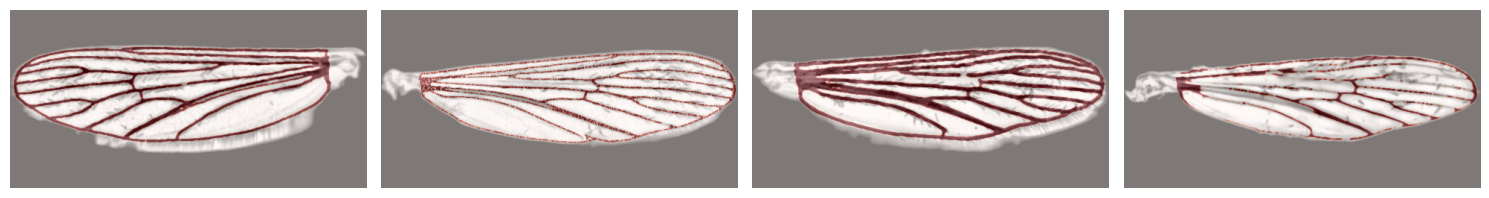

In [14]:
with torch.no_grad():
  for batch, (img, y, weight, path) in enumerate(train_dataloader):
      # Compute prediction and loss
      img = img.to(device)
      y = y.to(device)
      weight = weight.to(device)

      # segmentation prediction (B,1,H,W)
      segment = segmentation_model(img)
      segment = torch.sigmoid(segment)

      # apply albumentations per-sample
      segment_aug = apply_albumentations_batch_simple(segment, segment_trans)

      # resize and continue as before
      image_imgsize = TF.resize(img, (image_height, image_width))
      segment_imgsize = TF.resize(segment_aug, (image_height, image_width))
      break

segmentation = segment_imgsize.cpu().detach().numpy()
image = image_imgsize.cpu().detach().numpy()

fig, ax = plt.subplots(1,4, figsize=(15,5))

for i in range(4):
  ax[i].imshow(image[i][0], cmap="Greys_r")
  ax[i].imshow(segmentation[i][0], cmap="Reds", alpha=.5)
  ax[i].axis("off")

plt.tight_layout()

In [15]:
# ---------------------- TRAINING ---------------------- #
# Define scheduler
def lr_lambda(current_epoch):
    if current_epoch < warmup_epochs:
        # Linear warm-up
        return warmup_factor + (1 - warmup_factor) * (current_epoch / warmup_epochs)
    else:
        # Cosine decay
        progress = (current_epoch - warmup_epochs) / (epochs - warmup_epochs)
        return 0.5 * (1 + math.cos(math.pi * progress))

# Define optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
# Create the LambdaLR scheduler
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)

def train_loop(dataloader, model, epoch):
    model.train()
    total_loss = 0
    total_IoU = 0
    total_batches = len(dataloader)

    for batch, (img, y, weight, path) in enumerate(dataloader):
        # Compute prediction and loss
        img = img.to(device)
        y = y.to(device)
        weight = weight.to(device)

        # segmentation prediction (B,1,H,W)
        segment = segmentation_model(img)
        segment = torch.sigmoid(segment)  # keep on GPU

        # apply albumentations per-sample (simple wrapper)
        segment_aug = apply_albumentations_batch_simple(segment, segment_trans)

        # resize and continue as before
        image_imgsize = TF.resize(img, (image_height, image_width))
        segment_imgsize = TF.resize(segment_aug, (image_height, image_width))

        pred = model(image_imgsize, segment_imgsize)
        loss = custom_loss(pred, y, weight, alpha=alpha)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        # Calculate metrics
        pred_sigmoid = torch.sigmoid(pred)

        total_loss += loss.item()
        tp, fp, fn, tn = smp.metrics.get_stats(pred_sigmoid > .5, y > .5, mode='binary')
        total_IoU += smp.metrics.iou_score(tp, fp, fn, tn).mean()


    # Average metrics for the epoch
    avg_loss = total_loss / total_batches
    avg_iou = total_IoU / total_batches

    print(f"Training Epoch {epoch}: Loss: {avg_loss:.3f}, IoU: {avg_iou:.3f}")

    scheduler.step()

def test_loop(dataloader, model, epoch):
    model.eval()
    total_loss = 0
    total_IoU = 0
    total_dist = 0
    total_batches = len(dataloader)

    with torch.no_grad():
        for batch, (img, y, weight, path) in enumerate(dataloader):
            # Compute prediction and loss
            img = img.to(device)
            y = y.to(device)
            weight = weight.to(device)

            # segmentation prediction (B,1,H,W)
            segment = segmentation_model(img)
            segment = torch.sigmoid(segment)

            # apply albumentations per-sample
            segment_aug = apply_albumentations_batch_simple(segment, segment_trans)

            # resize and continue as before
            image_imgsize = TF.resize(img, (image_height, image_width))
            segment_imgsize = TF.resize(segment_aug, (image_height, image_width))

            pred = model(image_imgsize, segment_imgsize)
            loss = custom_loss(pred, y, weight, alpha=alpha)

            # Calculate metrics
            pred_sigmoid = torch.sigmoid(pred)

            total_loss += loss.item()
            tp, fp, fn, tn = smp.metrics.get_stats(pred_sigmoid > .5, y > .5, mode='binary')
            total_IoU += smp.metrics.iou_score(tp, fp, fn, tn).mean()

            if batch == 0 or batch % 4 == 0:
              total_dist += landmark_pred_dist(pred, y).mean()

    # Average metrics for the epoch
    avg_loss = total_loss / total_batches
    avg_iou = total_IoU / total_batches
    if batch == 0 or batch % 4 == 0:
      avg_distance = total_dist / total_batches

    print(f"Testing {epoch}: Loss: {avg_loss:.3f}, IoU: {avg_iou:.3f}", "\n-------------------")

In [16]:
for t in range(epochs):
    train_loop(train_dataloader, model, t)
    test_loop(test_dataloader, model, t)

Training Epoch 0: Loss: 0.045, IoU: 0.092
Testing 0: Loss: 0.008, IoU: 0.167 
-------------------
Training Epoch 1: Loss: 0.015, IoU: 0.194
Testing 1: Loss: 0.005, IoU: 0.209 
-------------------
Training Epoch 2: Loss: 0.013, IoU: 0.213
Testing 2: Loss: 0.004, IoU: 0.225 
-------------------
Training Epoch 3: Loss: 0.013, IoU: 0.223
Testing 3: Loss: 0.004, IoU: 0.241 
-------------------
Training Epoch 4: Loss: 0.013, IoU: 0.231
Testing 4: Loss: 0.004, IoU: 0.259 
-------------------
Training Epoch 5: Loss: 0.012, IoU: 0.242
Testing 5: Loss: 0.004, IoU: 0.255 
-------------------
Training Epoch 6: Loss: 0.012, IoU: 0.247
Testing 6: Loss: 0.004, IoU: 0.257 
-------------------
Training Epoch 7: Loss: 0.012, IoU: 0.252
Testing 7: Loss: 0.004, IoU: 0.272 
-------------------
Training Epoch 8: Loss: 0.012, IoU: 0.258
Testing 8: Loss: 0.004, IoU: 0.284 
-------------------
Training Epoch 9: Loss: 0.012, IoU: 0.264
Testing 9: Loss: 0.004, IoU: 0.269 
-------------------
Training Epoch 10: L

In [17]:
# save pytorch model
path = "/content/drive/MyDrive/PhD/ITHILDIN/landmark/"
torch.save(model, path + "/{}/landmark_fold-{}_{}.pth".format(EXPERIMENT, fold, EXPERIMENT))
torch.save(model.state_dict(), path + "/{}/landmark_weights_fold-{}_{}.pth".format(EXPERIMENT, fold, EXPERIMENT))

In [18]:
np.save(path + "/{}/test_files_fold-{}_{}.npy".format(EXPERIMENT, fold, EXPERIMENT), np.asarray([str(x) for x in test_path_list]))